DriveValue AI
 An Explainable Machine Learning Framework for Predicting Used Car Prices

## Capstone Project

Author: Jacqualine Makgolana

---

 Business Problem

Pricing a used car accurately is one of the biggest challenges in the automotive market. Factors such as age, mileage, brand, fuel type, ownership history, and transmission all influence the resale value of a vehicle.

This project aims to build a machine learning model capable of predicting the asking price of a used car while identifying the key factors that drive vehicle prices.

---

 Project Objectives

- Understand the dataset
- Perform data quality assessment
- Clean and preprocess the data
- Explore patterns and relationships
- Engineer meaningful features
- Build and compare regression models
- Tune the best-performing model
- Explain model predictions
- Provide business recommendations

## CRISP-DM Phase

This notebook covers the first two phases of the CRISP-DM methodology:

- Business Understanding
- Data Understanding

The objective is to gain an understanding of the dataset, assess its quality, identify potential issues, and perform the initial cleaning required before exploratory analysis and machine learning.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../Data/raw/used_cars_dataset.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,"98,000 km",NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,NaN,NaN,15.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [3]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names")

for column in df.columns:
    print(f"• {column}")

DATASET OVERVIEW
Number of Rows    : 24,575
Number of Columns : 11

Column Names
• Brand
• model
• Year
• Age
• kmDriven
• Transmission
• Owner
• FuelType
• PostedDate
• AdditionInfo
• AskPrice


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         19306 non-null  str    
 1   model         14144 non-null  str    
 2   Year          19396 non-null  float64
 3   Age           18600 non-null  float64
 4   kmDriven      18344 non-null  str    
 5   Transmission  18653 non-null  str    
 6   Owner         13949 non-null  str    
 7   FuelType      19336 non-null  str    
 8   PostedDate    18355 non-null  str    
 9   AdditionInfo  24575 non-null  str    
 10  AskPrice      24575 non-null  str    
dtypes: float64(2), str(9)
memory usage: 2.1 MB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,19306,41,Unknown,5125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,14144,403,Wagon-R,589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,19396.0,NaN,NaN,NaN,4118.984327,3516.311608,1900.0,2015.0,2018.0,9999.0,9999.0
Age,18600.0,NaN,NaN,NaN,7.676398,4.293379,0.0,5.0,7.0,10.0,124.0
kmDriven,18344,2303,"75,000 km",351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,18653,2,Automatic,9418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,13949,2,second,7289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FuelType,19336,5,Petrol,5447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PostedDate,18355,12,Nov-24,16323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdditionInfo,24575,10676,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel",56,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

missing

,Missing Values,Percentage (%)
Owner,10626,43.24
model,10431,42.45
kmDriven,6231,25.36
PostedDate,6220,25.31
Age,5975,24.31
Transmission,5922,24.10
Brand,5269,21.44
FuelType,5239,21.32
Year,5179,21.07
AdditionInfo,0,0.00


In [7]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 9587


In [8]:
df["AskPrice"].describe()

count          24575
unique          1616
top       ₹ 4,50,000
freq             355
Name: AskPrice, dtype: object

# Initial Data Audit Findings #

### Dataset Overview 

The following observations were made from the dataset:

- The dataset contains both numerical and categorical variables.
- Missing values are present in multiple features and require appropriate treatment.
- Duplicate records were assessed as part of the data quality audit.
- The target variable (AskPrice) will be analysed further during exploratory data analysis.

Next we will work on understanding the distribution of variables, identifying relationships between features, and uncovering the key drivers of used car prices.

In [9]:
quality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df)*100).round(2),
    "Unique Values": df.nunique()
})

quality

,Data Type,Missing Values,Missing %,Unique Values
Brand,str,5269,21.44,41
model,str,10431,42.45,403
Year,float64,5179,21.07,36
Age,float64,5975,24.31,33
kmDriven,str,6231,25.36,2303
Transmission,str,5922,24.10,2
Owner,str,10626,43.24,2
FuelType,str,5239,21.32,5
PostedDate,str,6220,25.31,12
AdditionInfo,str,0,0.00,10676


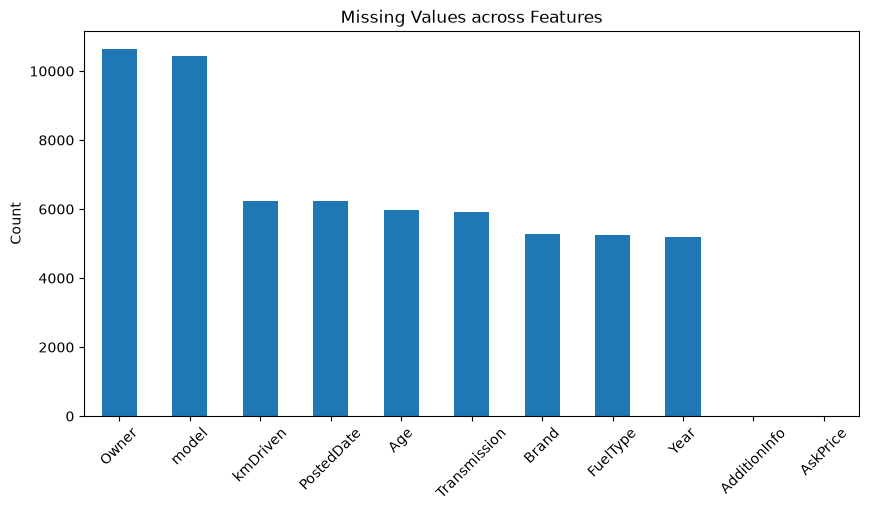

In [10]:
import matplotlib.pyplot as plt

missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

missing.plot(kind="bar")

plt.title("Missing Values across Features")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [11]:
missing_percent = (df.isnull().sum()/len(df)*100)\
                    .sort_values(ascending=False)

missing_percent

Owner           43.239064
model           42.445575
kmDriven        25.355036
PostedDate      25.310275
Age             24.313327
Transmission    24.097660
Brand           21.440488
FuelType        21.318413
Year            21.074262
AdditionInfo     0.000000
AskPrice         0.000000
dtype: float64

## Data Quality Observations ##

The initial quality assessment revealed that several features contain missing values.

The highest levels of missingness occur within categorical variables such as Owner and Model, while numerical features such as kmDriven also contain incomplete records.

These missing values cannot simply be removed without first evaluating their potential impact on the predictive model. Appropriate imputation strategies will therefore be considered during the preprocessing stage.

# Understanding the Dataset #

Before exploring relationships between variables, it is important to understand what each feature represents and how it may influence the asking price of a used vehicle.

In [12]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Column,Data Type,Non-Null Count,Missing Values,Unique Values
0,Brand,str,19306,5269,41
1,model,str,14144,10431,403
2,Year,float64,19396,5179,36
3,Age,float64,18600,5975,33
4,kmDriven,str,18344,6231,2303
5,Transmission,str,18653,5922,2
6,Owner,str,13949,10626,2
7,FuelType,str,19336,5239,5
8,PostedDate,str,18355,6220,12
9,AdditionInfo,str,24575,0,10676


### Interpretation

The dataset consists of a mixture of numerical and categorical variables with varying levels of completeness.

While several variables contain substantial missing values, every feature remains potentially valuable for predicting vehicle prices. Rather than removing observations prematurely, missing values will be addressed during preprocessing using appropriate imputation techniques.

The dataset also contains duplicate observations and inconsistent data formats that require cleaning before exploratory analysis.

# Data Quality Assesment

A high-quality dataset is essential for developing accurate and reliable machine learning models. Therefore, this assessment focuses on identifying missing values, duplicate records, inconsistent data types, and other potential issues that could impact model performance.

## Transition to Data Cleaning

Following the initial assessment, several data quality issues were identified that could negatively affect model performance.

The next stage focuses on preparing the dataset by removing duplicate observations, correcting inconsistent data formats, and resolving invalid values before exploratory data analysis.

# Data Cleaning Preparation

In [13]:
df.dtypes

Brand               str
model               str
Year            float64
Age             float64
kmDriven            str
Transmission        str
Owner               str
FuelType            str
PostedDate          str
AdditionInfo        str
AskPrice            str
dtype: object

In [14]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 9587


In [15]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,"98,000 km",NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,NaN,NaN,15.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"
5,BMW,NaN,2014.0,NaN,"83,000 km",NaN,first,Unknown,Nov-24,"BMW X3 2.0 XDRIVE 20D, 2014, Diesel","₹ 13,50,000"
6,Unknown,NaN,NaN,10.0,"168,000 km",Manual,second,Diesel,Nov-24,"Toyota Innova 2.5 VX 8 Seater BS IV, 2014, Diesel","₹ 10,25,000"
7,BMW,NaN,2019.0,5.0,NaN,Automatic,NaN,Diesel,Nov-24,"BMW 5 Series 3.0 530D M Sport, 2019, Diesel","₹ 59,50,000"
8,Maruti Suzuki,NaN,9999.0,NaN,"33,759 km",Manual,NaN,Petrol,Nov-24,"Maruti Suzuki Dzire 1.2 VXI, 2020, Petrol","₹ 6,22,000"
9,Ford,Ecosport,9999.0,NaN,NaN,Manual,second,NaN,NaN,"Ford Ecosport 1.5 Ti VCT MT Titanium BE, 2017,...","₹ 6,49,000"


In [16]:
duplicate_percentage = (df.duplicated().sum() / len(df)) * 100

print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Percentage of duplicates: {duplicate_percentage:.2f}%")

Duplicate rows: 9587
Percentage of duplicates: 39.01%


In [17]:
df_no_duplicates = df.drop_duplicates()

print(f"Original rows: {len(df)}")
print(f"Rows after removing duplicates: {len(df_no_duplicates)}")
print(f"Rows removed: {len(df) - len(df_no_duplicates)}")

Original rows: 24575
Rows after removing duplicates: 14988
Rows removed: 9587


In [18]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(by=list(df.columns)).head(20)

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
8772,Ambassador,NaN,9999.0,21.0,1 km,NaN,second,NaN,Nov-24,Ambassador isuzu,"₹ 1,55,000"
18354,Ambassador,NaN,9999.0,21.0,1 km,NaN,second,NaN,Nov-24,Ambassador isuzu,"₹ 1,55,000"
3383,Audi,A3,2015.0,NaN,"42,000 km",NaN,NaN,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
12965,Audi,A3,2015.0,NaN,"42,000 km",NaN,NaN,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
2455,Audi,A3,2015.0,NaN,"42,000 km",NaN,NaN,NaN,NaN,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
12037,Audi,A3,2015.0,NaN,"42,000 km",NaN,NaN,NaN,NaN,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
3171,Audi,A3,9999.0,8.0,NaN,NaN,second,NaN,NaN,"Audi A3 35 TDI S Line, 2016, Diesel","₹ 9,49,000"
12753,Audi,A3,9999.0,8.0,NaN,NaN,second,NaN,NaN,"Audi A3 35 TDI S Line, 2016, Diesel","₹ 9,49,000"
23,Audi,A3,9999.0,9.0,"42,000 km",Automatic,NaN,NaN,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
9605,Audi,A3,9999.0,9.0,"42,000 km",Automatic,NaN,NaN,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"


## Duplicate Records

A total of 9,587 duplicate records (39.01%) were identified in the dataset.

Inspection confirmed that these records were exact duplicates rather than distinct vehicles with similar attributes. To prevent duplicate observations from biasing the machine learning model, duplicate rows will be removed while retaining the first occurrence of each record.

In [19]:
df = df.drop_duplicates()

print(f"New dataset shape: {df.shape}")

New dataset shape: (14988, 11)


In [20]:
df["AskPrice"] = (
    df["AskPrice"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

df["AskPrice"].head()

0    195000
1    375000
2    184999
3    565000
4    685000
Name: AskPrice, dtype: int64

In [21]:
df["kmDriven"] = (
    df["kmDriven"]
    .str.replace(" km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(".0", "", regex=False)
)

df["kmDriven"] = pd.to_numeric(df["kmDriven"], errors="coerce")

df["kmDriven"].head()

0     98000.0
1    190000.0
2         NaN
3         NaN
4         NaN
Name: kmDriven, dtype: float64

In [22]:
df["kmDriven"].dtype

dtype('float64')

## Correcting Invalid Year Values

Inspection of the **Year** feature revealed that a substantial number of records contained the value **9999**, which is not a valid vehicle manufacturing year. These values would distort statistical analysis and negatively affect the machine learning model if left uncorrected.

To preserve as much information as possible, the invalid values were handled using the following approach:

- Where the vehicle's **Age** was available, the manufacturing year was estimated using:
  
  **Year = 2024 − Age**

- Where both **Year** and **Age** were unavailable, the invalid value was replaced with a missing value (`NaN`) so that it could be handled appropriately during preprocessing.

This approach improves data quality while minimizing unnecessary information loss.

In [23]:
df["Year"].describe()

count    12391.000000
mean      3666.820192
std       3233.002118
min       1900.000000
25%       2015.000000
50%       2018.000000
75%       2022.000000
max       9999.000000
Name: Year, dtype: float64

In [24]:
df["Year"].value_counts().sort_index().tail(10)

Year
2016.0     936
2017.0    1028
2018.0    1077
2019.0     833
2020.0     544
2021.0     562
2022.0     524
2023.0     342
2024.0     191
9999.0    2562
Name: count, dtype: int64

In [26]:
df.loc[
    (df["Year"] == 9999) & (df["Age"].notna()),
    "Year"
] = 2024 - df.loc[
    (df["Year"] == 9999) & (df["Age"].notna()),
    "Age"
]

In [28]:
(df["Year"] == 9999).sum()

np.int64(703)

In [29]:
df.loc[df["Year"] == 9999, "Year"] = np.nan

In [30]:
df["Year"].describe()

count    11688.000000
mean      2016.298169
std          4.413277
min       1900.000000
25%       2014.000000
50%       2017.000000
75%       2019.000000
max       2024.000000
Name: Year, dtype: float64

In [31]:
df.to_csv("../Data/processed/used_cars_cleaned.csv", index=False)

print(" Cleaned dataset saved successfully!")

 Cleaned dataset saved successfully!


# Notebook 1 Conclusion

I have identified several issues that required correction before modelling.

### Key Findings
- Original observations: 24,575
- Duplicate records removed: 9,587
- Final observations: 14,988
- AskPrice converted to numeric.
- kmDriven converted to numeric.
- Invalid Year values corrected using Age where possible.
- Remaining invalid Year values converted to missing values.
- Cleaned dataset exported for exploratory data analysis.

The data quality assessment and initial cleaning process successfully prepared the dataset for the next stage of the CRISP-DM methodology.

Major quality issues: including duplicate records, inconsistent numerical formats, and invalid manufacturing years—were identified and addressed while preserving as much useful information as possible.

The cleaned dataset has been exported and is now ready for exploratory data analysis, where feature distributions, relationships, and potential predictors of vehicle prices will be investigated.